In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import stylia
import pandas as pd
import numpy as np
import os

In [2]:
pathogens = [
    ("abaumannii",   "A. baumannii"),
    ("calbicans",    "C. albicans"),
    ("campylobacter","Campylobacter"),
    ("ecoli",        "E. coli"),
    ("efaecium",     "E. faecium"),
    ("enterobacter", "Enterobacter"),
    ("hpylori",      "H. pylori"),
    ("kpneumoniae",  "K. pneumoniae"),
    ("mtuberculosis","M. tuberculosis"),
    ("ngonorrhoeae", "N. gonorrhoeae"),
    ("paeruginosa",  "P. aeruginosa"),
    ("pfalciparum",  "P. falciparum"),
    ("saureus",      "S. aureus"),
    ("smansoni",     "S. mansoni"),
    ("spneumoniae",  "S. pneumoniae"),
]

PATH_TO_OUTPUT = os.path.join(".", "..", "output")
THRESHOLD = 0.6
MIN_CPDS = 50

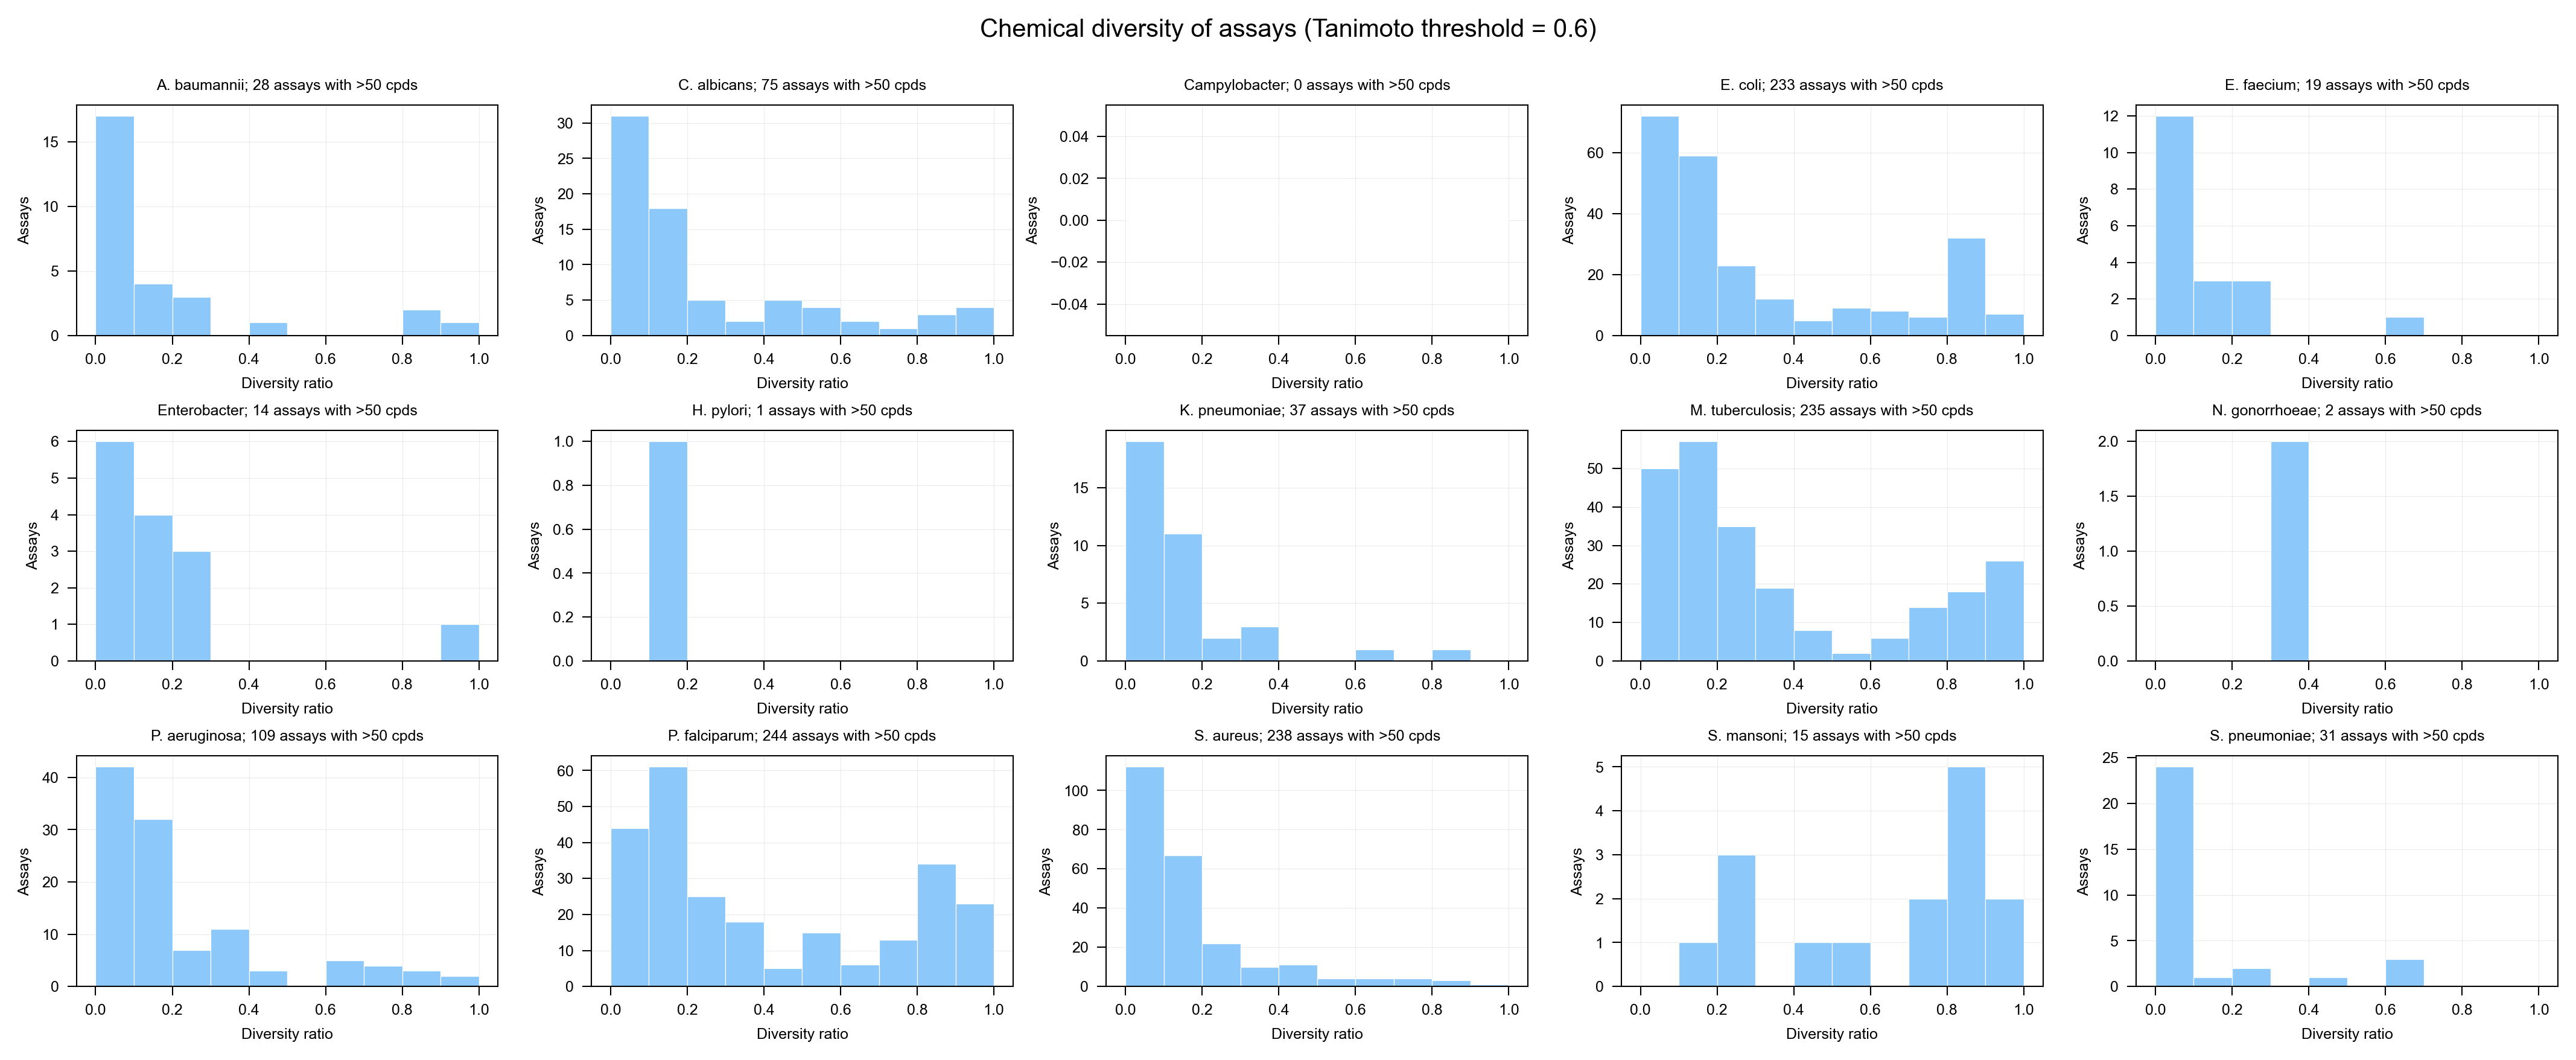

In [20]:
ec = stylia.ErsiliaColors()
col = f"clusters_{THRESHOLD}"

fig, axs = stylia.create_figure(3, 5, width=2, height=0.8)

for code, name in pathogens:
    df = pd.read_csv(os.path.join(PATH_TO_OUTPUT, code, "10_assays_clusters.csv"))
    df = df[df["cpds"] > MIN_CPDS].copy()
    df["ratio"] = df[col] / df["cpds"]

    ax = axs.next()
    ax.hist(df["ratio"], bins=[i for i in np.arange(0, 1.0001, 0.1)], color=ec.blue, edgecolor="w", linewidth=0.3, zorder=2)
    title = f"{name}; {len(df)} assays with >{MIN_CPDS} cpds"
    stylia.label(ax, xlabel="Diversity ratio", ylabel="Assays", title=title)
    ax.set_xlim(-0.05, 1.05)

fig.suptitle(f"Chemical diversity of assays (Tanimoto threshold = {THRESHOLD})", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()